# Analysis Jupyter Notebook

This notebook contains preliminary analysis for Supernova themepark, using the newly-created analysis database. Analysis includes:

- Ticeket Revenue by Day of Week

- Distribution of Purchases per Guest ID

- Distribution of Ratings per Attraction Ride

In [2]:
# imports
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# checks for db existence in current or parent directory (base repo folder)
candidate_roots = [Path.cwd(), Path.cwd().parent]
# loops thru candidate_roots to find db
repo_root = next((root for root in candidate_roots if (root / 'data' / 'themepark_analysis.db').exists()), None)

# Raise error if db not run through script
if repo_root is None:
    raise FileNotFoundError(
        "Build data/themepark_analysis.db first by running ./scripts/build_analysis_db.sh from the repo root."
    )

# db connection
db_path = repo_root / 'data' / 'themepark_analysis.db'
connection = sqlite3.connect(db_path)
cursor = connection.cursor()

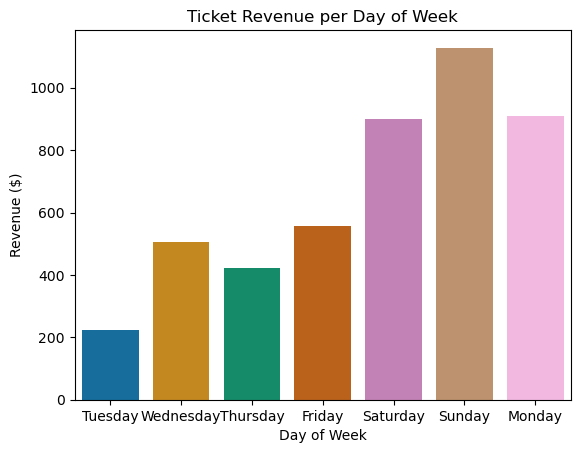

In [4]:
# Query 1 Figure

query1 = """
WITH daily_revenue AS (
    SELECT
        v.visit_date,
        d.day_name,
        SUM(v.spend_dollar) AS day_revenue
    FROM vw_fact_visits_clean v
    LEFT JOIN dim_date d ON v.date_id = d.date_id
    GROUP BY v.visit_date, d.day_name
)
SELECT
    visit_date,
    day_name,
    day_revenue
FROM daily_revenue
ORDER BY visit_date;
"""

df1 = pd.read_sql_query(query1, connection)

sns.barplot(df1, x='day_name', y='day_revenue', hue='day_name', palette='colorblind', legend=False)
plt.ylabel('Revenue ($)')
plt.xlabel('Day of Week')
plt.title('Ticket Revenue per Day of Week')
plt.show()

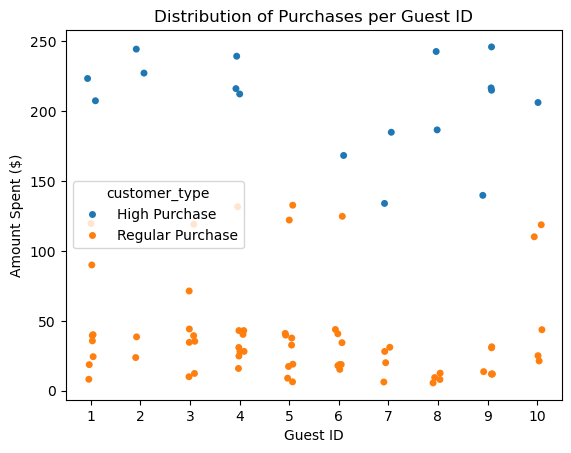

In [5]:
# Query 2 Figure

query2 = """
WITH all_purchases AS (
    SELECT
        g.guest_id,
        g.first_name || ' ' || g.last_name AS guest_name,
        v.spend_dollar AS amount_dollar,
        'Ticket Spend' AS spend_type
    FROM vw_fact_visits_clean v
    INNER JOIN vw_dim_guest_clean g ON v.guest_id = g.guest_id
    WHERE v.spend_dollar IS NOT NULL

    UNION ALL

    SELECT
        g.guest_id,
        g.first_name || ' ' || g.last_name AS guest_name,
        p.amount_dollar AS amount_dollar,
        'In-Park Purchase' AS spend_type
    FROM vw_fact_purchases_clean p
    INNER JOIN vw_fact_visits_clean v ON p.visit_id = v.visit_id
    INNER JOIN vw_dim_guest_clean g ON v.guest_id = g.guest_id
    WHERE p.amount_dollar IS NOT NULL
)
SELECT
    guest_id,
    guest_name,
    amount_dollar,
    spend_type,
    CASE
        WHEN amount_dollar >= 133.94 THEN 'High Purchase'
        ELSE 'Regular Purchase'
    END AS customer_type
FROM all_purchases;
"""

df2 = pd.read_sql_query(query2, connection)
sns.stripplot(df2, x='guest_id', y='amount_dollar', hue='customer_type')
plt.xlabel('Guest ID')
plt.ylabel('Amount Spent ($)')
plt.title('Distribution of Purchases per Guest ID')
plt.show()

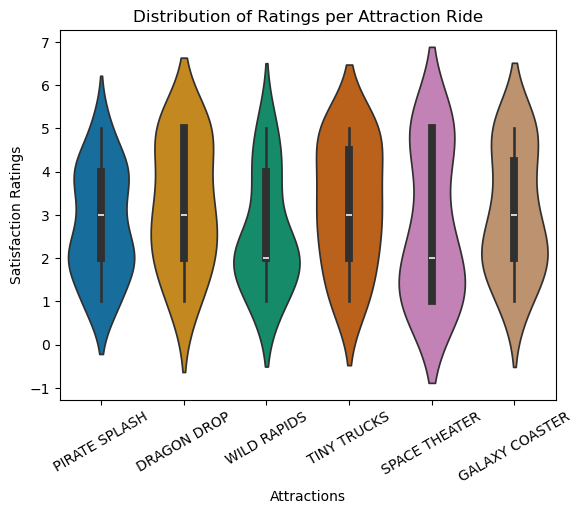

In [6]:
# Query 3 Figure

query3 = """
SELECT
    attraction_name_clean,
    satisfaction_rating
FROM vw_fact_ride_events_clean
WHERE satisfaction_rating IS NOT NULL;
"""

df3 = pd.read_sql_query(query3, connection)
sns.violinplot(
    df3,
    x='attraction_name_clean',
    y='satisfaction_rating',
    hue='attraction_name_clean',
    palette='colorblind',
    legend=False
 )
plt.xlabel('Attractions')
plt.ylabel('Satisfaction Ratings')
plt.title('Distribution of Ratings per Attraction Ride')
plt.xticks(rotation=30)
# plt.ylim(0, 5)
plt.show()